# 1- Title and Project Description
--------------------------------
# Garbage Classification using Deep Learning (ResNet18)

Project Goal
------------
Build an image classification model capable of identifying waste materials
to improve recycling sorting systems.

Dataset
-------
Garbage classification dataset containing 6 classes:

- cardboard
- glass
- metal
- paper
- plastic
- trash

Approach
--------
We train a convolutional neural network (ResNet18 pretrained on ImageNet)
and fine-tune it for waste classification.

Evaluation
----------
The model is evaluated using accuracy, confusion matrix,
and prediction visualization.


 # 2- Imports

In [14]:
import os
import time
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix

# 3- Device Configuration

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# 4- Reproducibility (Seeds)

In [16]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 5- Dataset Path

In [17]:
data_dir = "/Users/ounissifadoua/Downloads/garbage-classification/Garbage/original_images"

# 6- Image Transformations

In [18]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# 7- Load Dataset

In [19]:
dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Number of images:", len(dataset))
print("Classes:", dataset.classes)

Number of images: 2527
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


# 8- Dataset Visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.129035].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8458387..1.9577874].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8256302..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5778649..2.1804092].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..2.0947855].


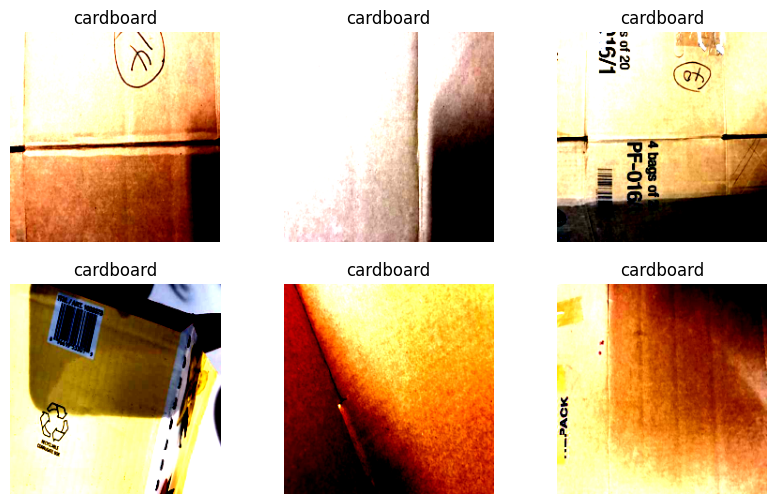

In [20]:
def show_samples(dataset):

    fig, axes = plt.subplots(2,3, figsize=(10,6))

    for i, ax in enumerate(axes.flatten()):

        img, label = dataset[i]

        img = img.permute(1,2,0)

        ax.imshow(img)
        ax.set_title(dataset.classes[label])
        ax.axis("off")

    plt.show()

show_samples(dataset)

# 9- Dataset Class Distribution

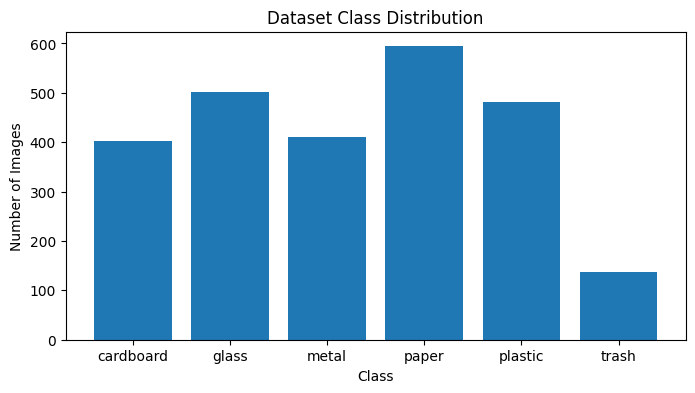

In [21]:
import collections

labels = [label for _, label in dataset]

counter = collections.Counter(labels)

classes = dataset.classes
values = [counter[i] for i in range(len(classes))]

plt.figure(figsize=(8,4))

plt.bar(classes, values)

plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

# 10- Train / Validation / Test Split

In [22]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

# 11- DataLoaders

In [23]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32)

test_loader = DataLoader(test_dataset, batch_size=32)

# 12- Model Definition (ResNet18)

In [24]:
model = models.resnet18(weights="DEFAULT")

model.fc = nn.Linear(model.fc.in_features, 6)

model = model.to(device)

# 13- Loss and Optimizer

In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# 14- Training Loop

In [26]:

num_epochs = 10 
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")


Epoch 1/10 - Loss: 0.9881, Accuracy: 0.6629
Epoch 2/10 - Loss: 0.5848, Accuracy: 0.7958
Epoch 3/10 - Loss: 0.4607, Accuracy: 0.8462
Epoch 4/10 - Loss: 0.3829, Accuracy: 0.8575
Epoch 5/10 - Loss: 0.3771, Accuracy: 0.8614
Epoch 6/10 - Loss: 0.2614, Accuracy: 0.9146
Epoch 7/10 - Loss: 0.1644, Accuracy: 0.9429
Epoch 8/10 - Loss: 0.1555, Accuracy: 0.9531
Epoch 9/10 - Loss: 0.1735, Accuracy: 0.9434
Epoch 10/10 - Loss: 0.1248, Accuracy: 0.9553


# 15-Training Visualization

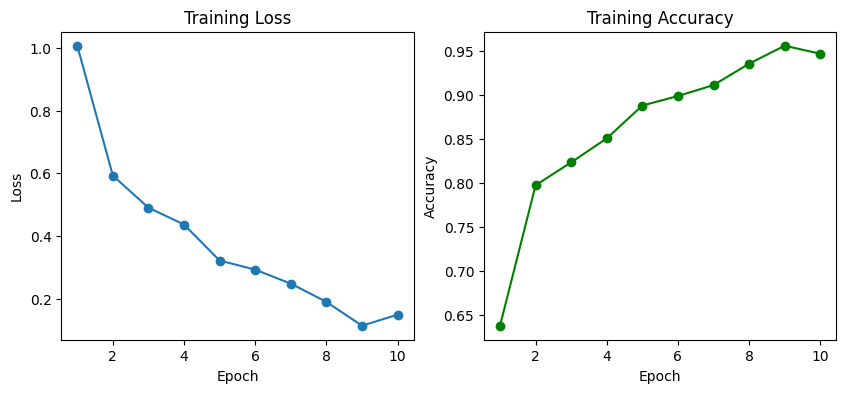

In [29]:
import matplotlib.pyplot as plt

# Training history (example from your logs)
epochs = range(1, 11)
train_loss = [1.0062, 0.5926, 0.4907, 0.4370, 0.3226, 0.2935, 0.2491, 0.1911, 0.1151, 0.1502]
train_acc = [0.6380, 0.7975, 0.8235, 0.8507, 0.8880, 0.8988, 0.9112, 0.9355, 0.9559, 0.9468]

# Plot Loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_loss, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_acc, marker='o', color='green')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

 # 16- Model Evaluation

In [30]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

# 17- Confusion Matrix

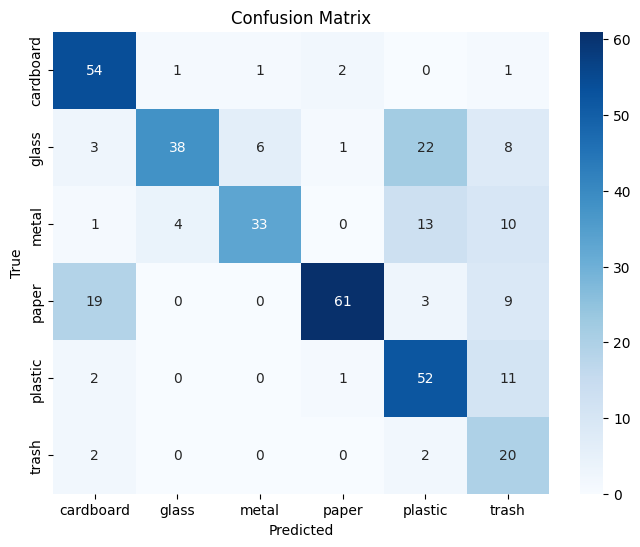

In [31]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

# 18- Classification Report

In [32]:
print(classification_report(
    y_true,
    y_pred,
    target_names=dataset.classes
))

              precision    recall  f1-score   support

   cardboard       0.67      0.92      0.77        59
       glass       0.88      0.49      0.63        78
       metal       0.82      0.54      0.65        61
       paper       0.94      0.66      0.78        92
     plastic       0.57      0.79      0.66        66
       trash       0.34      0.83      0.48        24

    accuracy                           0.68       380
   macro avg       0.70      0.70      0.66       380
weighted avg       0.76      0.68      0.69       380



# 19- Show Predictions

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7172985..2.1345534].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7754089..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.3088455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8458387..1.9577874].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.3585434].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6330532..2.5702832].


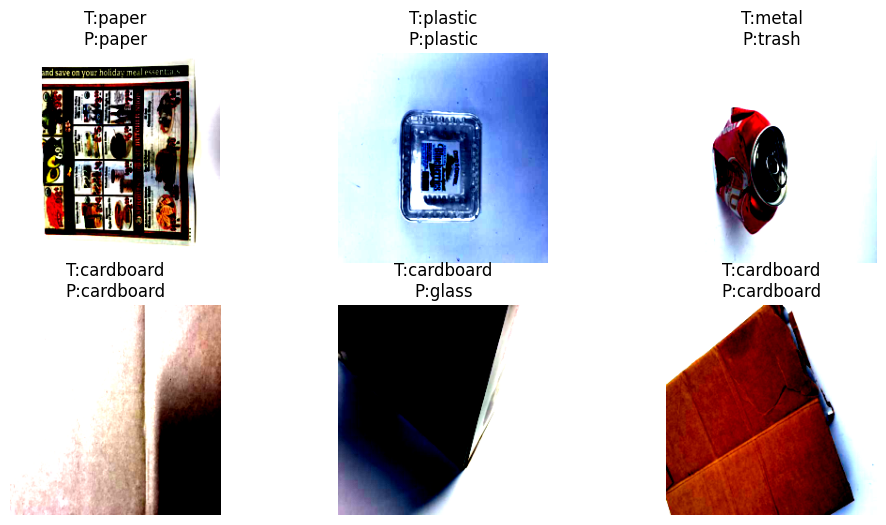

In [33]:
images, labels = next(iter(test_loader))

outputs = model(images.to(device))

_, preds = torch.max(outputs,1)

plt.figure(figsize=(12,6))

for i in range(6):

    img = images[i].permute(1,2,0)

    plt.subplot(2,3,i+1)
    plt.imshow(img)

    plt.title(f"T:{dataset.classes[labels[i]]}\nP:{dataset.classes[preds[i]]}")

    plt.axis("off")

plt.show()

# 20- Saving the Model as .h5 for Web Deployment
------------------------------------------------------------


Use the .h5 model in the web application
----------------------------------

In [42]:
save_path = "/Users/ounissifadoua/Downloads/model.h5"

import os
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(model.state_dict(), save_path)
print(f"Model saved at: {save_path}")

Model saved at: /Users/ounissifadoua/Downloads/model.h5


In [45]:
!git init



hint: Using 'master' as the name for the initial branch. This default branch name
hint: will change to "main" in Git 3.0. To configure the initial branch name
hint: to use in all of your new repositories, which will suppress this warning,
hint: call:
hint:
hint: 	git config --global init.defaultBranch <name>
hint:
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint:
hint: 	git branch -m <name>
hint:
hint: Disable this message with "git config set advice.defaultBranchName false"
Initialized empty Git repository in /Users/ounissifadoua/.git/


In [47]:
!git remote add origin https://github.com/fadou4/AI-model.git

In [ ]:
!git add ResNet.ipynb model.h5 


In [ ]:
!git commit -m "Add ResNet notebook and model"


In [ ]:
!git push -u origin main

In [ ]:
!git branch

In [ ]:
!git push -u origin master

In [ ]:
!git branch -M main


In [ ]:
!git push -u origin main

In [ ]:
!git log -1 --oneline